# 睡眠品質予測（モデリング）
## 加工データの呼び出し

In [1]:
import pandas as pd

df = pd.read_csv("data/processed/Sleep_health_and_lifestyle_dataset_processed.csv")
df.head()

,Unnamed: 0,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic,BP_PC1
0,0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No,126,83,-0.422924
1,1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No,125,80,-0.859049
2,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No,125,80,-0.859049
3,3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Yes,140,90,1.660849
4,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Yes,140,90,1.660849


In [2]:
df.shape

(374, 16)

In [3]:
df.info()  # 欠損値とデータタイプの確認

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    str    
 13  Systolic                 374 non-null    int64  
 14  Diastolic                374 non-null

In [4]:
df.describe()

,Unnamed: 0,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic,BP_PC1
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,3.740000e+02
mean,186.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733,-3.039755e-16
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611,1.406476e+00
min,0.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000,-2.347458e+00
25%,93.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000,-8.590492e-01
50%,186.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000,1.724397e-01
75%,279.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000,1.203929e+00
max,373.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000,2.235417e+00


In [5]:
# 欠損値の確認
df.isnull().sum()

Unnamed: 0                 0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic                   0
Diastolic                  0
BP_PC1                     0
dtype: int64

In [6]:
df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
No     219
Yes    155
Name: count, dtype: int64

## モデル比較

In [7]:
X = df.drop(columns=["Quality of Sleep"])
y = df["Quality of Sleep"]

In [8]:
categorical_features = [
    "Gender",
    "Occupation",
    "BMI Category",
    "Sleep Disorder"
]

numerical_features = [
    "Age",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic",
    "Diastolic"
]

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [11]:
from sklearn.pipeline import Pipeline

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [12]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}


results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "MAE": round(
            -scores["test_mae"].mean(),
            3
        ),
        "RMSE": round(
            -scores["test_rmse"].mean(),
            3
        ),
        "R2": round(
            scores["test_r2"].mean(),
            3
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
2,GradientBoosting,0.225,0.408,0.745
0,LinearRegression,0.304,0.426,0.740
1,RandomForest,0.272,0.430,0.704


In [13]:
# 全特徴量含む
features_all = [
    "Age",
    "Gender",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Heart Rate",
    "Daily Steps",
    "Sleep Disorder",
    "Systolic",
    "Diastolic",
    "BP_PC1"
]

### 性別について
女性は男性より深い睡眠が多く回復力も高い反面、ホルモン変動や社会的役割により主観的には睡眠の質が低下しやすいです。  
性別に応じた睡眠習慣の管理や生活環境の調整、必要に応じた医療対応が、睡眠の質改善と健康維持に重要であることが示されています 。  
※株式会社エフェクトより

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_validate,
    KFold
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np

In [15]:
def evaluate_feature_set(
    df,
    features,
    models
):

    X = df[features]
    y = df["Quality of Sleep"]

    categorical_features = (
        X.select_dtypes(include=["object"])
        .columns
        .tolist()
    )

    numerical_features = (
        X.select_dtypes(exclude=["object"])
        .columns
        .tolist()
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            ),
            (
                "num",
                "passthrough",
                numerical_features
            )
        ]
    )

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    results = []

    for name, model in models.items():

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        scores = cross_validate(
            pipeline,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True
        )

        results.append({
            "Model": name,
            
            "Train MAE": round(
                -scores["train_mae"].mean(),
                3
            ),
            "Test MAE": round(
                -scores["test_mae"].mean(),
                3
            ),
            
            "Train RMSE": round(
                -scores["train_rmse"].mean(),
                3
            ),
            "Test RMSE": round(
                -scores["test_rmse"].mean(),
                3
            ),

            "Train R2": round(
                scores["train_r2"].mean(),
                3
            ),
            "Test R2": round(
                scores["test_r2"].mean(),
                3
            )
        })

    return pd.DataFrame(results)

In [16]:
# features_all
evaluate_feature_set(
    df,
    features_all,
    models
)

/tmp/ipykernel_417548/3676999423.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include=["object"])


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,LinearRegression,0.203,0.225,0.272,0.311,0.948,0.930
1,RandomForest,0.017,0.047,0.066,0.158,0.997,0.981
2,GradientBoosting,0.011,0.039,0.025,0.145,1.000,0.984


In [17]:
df.corr["Quality of Sleep"].sort_values(ascending=False)


TypeError: 'method' object is not subscriptable

## 特徴量重要度確認
モデルの作成において、それぞれの特徴量がどれほど予測に貢献したのか、**SHAP値** を用いてさらに検討してみたい。

### 全特徴量で重要度について
どの特徴量を入力項目にするかを決めるために全特徴量で重要度を調べる。

In [18]:
X = df[features_all]
y = df["Quality of Sleep"]

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print(categorical_features)
print(numerical_features)

['Gender', 'BMI Category', 'Sleep Disorder']
['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic', 'BP_PC1']


/tmp/ipykernel_417548/4185291125.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Sleep Duration',...,'Systolic','Diastolic','BP_PC1']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis

In [22]:
feature_names = (
    pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    pipeline
    .named_steps["model"]
    .feature_importances_
)

print(len(importances))

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df

16


,Feature,Importance
8,num__Sleep Duration,7.613934e-01
10,num__Stress Level,1.645547e-01
11,num__Heart Rate,2.737797e-02
7,num__Age,2.222616e-02
12,num__Daily Steps,7.201877e-03
2,cat__BMI Category_Normal,4.968631e-03
15,num__BP_PC1,4.371403e-03
9,num__Physical Activity Level,3.538285e-03
13,num__Systolic,1.853852e-03
14,num__Diastolic,1.750588e-03


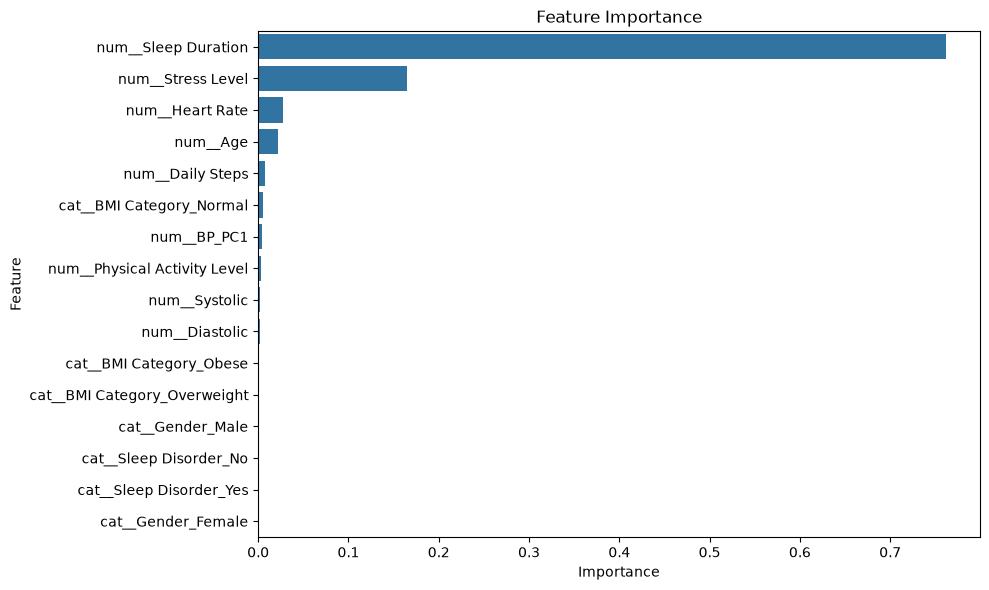

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

EDAでは女性の睡眠の質が男性より高い傾向が確認された。しかし、SHAPによる特徴量重要度ではGenderの寄与はほぼ見られず、さらにGenderを除いたモデルの方が予測精度は向上した。これは、本データセットにおける男女差は性別そのものではなく、睡眠時間やストレスレベルなど他の特徴量によって説明できる可能性を示している。

### 選んだ特徴量でモデルの作成

In [24]:
# アプリ向け（重要度が下の2つ分は削除）
features_app_1 = [
    "Age",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Heart Rate",
    "Daily Steps",
    "BP_PC1"
]

# アプリ向け(血圧と運動時間も削除)
features_app_2 = [
    "Age",
    "Sleep Duration",
    "Stress Level",
    "BMI Category",
    "Daily Steps",
    "Heart Rate"
]

In [25]:
# features_app
evaluate_feature_set(
    df,
    features_app_1,
    models
)

/tmp/ipykernel_417548/3676999423.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include=["object"])


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,LinearRegression,0.222,0.239,0.292,0.325,0.940,0.924
1,RandomForest,0.017,0.047,0.065,0.154,0.997,0.982
2,GradientBoosting,0.010,0.040,0.025,0.147,1.000,0.982


In [26]:
# features_app_use
evaluate_feature_set(
    df,
    features_app_2,
    models
)

/tmp/ipykernel_417548/3676999423.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include=["object"])


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,LinearRegression,0.223,0.239,0.295,0.326,0.939,0.923
1,RandomForest,0.017,0.047,0.068,0.151,0.997,0.982
2,GradientBoosting,0.014,0.046,0.035,0.149,0.999,0.981


In [28]:
X = df[features_app_2]
y = df["Quality of Sleep"]

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print(categorical_features)
print(numerical_features)

['BMI Category']
['Age', 'Sleep Duration', 'Stress Level', 'Daily Steps', 'Heart Rate']


/tmp/ipykernel_417548/823117510.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Age','Sleep Duration','Stress Level','BMI Category','Daily Steps', 'Heart Rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

In [32]:
feature_names = (
    pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    pipeline
    .named_steps["model"]
    .feature_importances_
)

print(len(importances))

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df

8


,Feature,Importance
4,num__Sleep Duration,0.765904
5,num__Stress Level,0.164399
7,num__Heart Rate,0.029074
3,num__Age,0.025133
6,num__Daily Steps,0.009199
0,cat__BMI Category_Normal,0.005697
1,cat__BMI Category_Obese,0.000356
2,cat__BMI Category_Overweight,0.000238


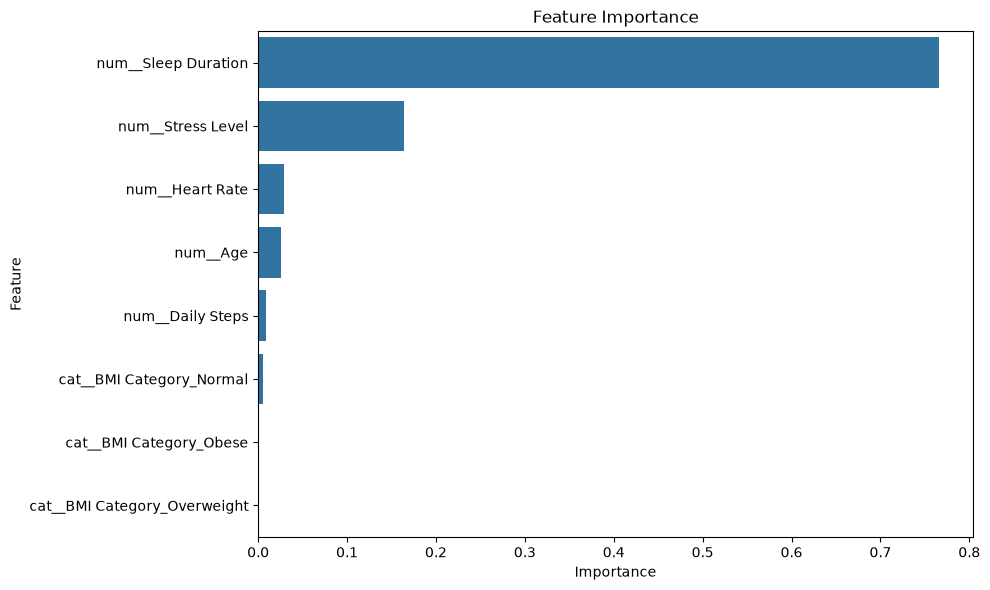

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## モデルの保存

In [34]:
import joblib

joblib.dump(
    pipeline,
    "models/sleep_quality_model.pkl"
)


['models/sleep_quality_model.pkl']

In [35]:
# 読み込み
model = joblib.load(
    "models/sleep_quality_model.pkl"
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Age','Sleep Duration','Stress Level','BMI Category','Daily Steps', 'Heart Rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o